# Analysis model SimpleCNN

## v2: simplecnn_lrsche_plat

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import numpy as np

In [3]:
CURRENT_WORKING_DIR = Path.cwd().resolve().parent

print(CURRENT_WORKING_DIR)

/home/nii/Documents/[code]sgu-2026-faical-expression-recognition


In [4]:
# **Layout:**
# ┌─────────────────┬─────────────────┐
# │                 │  Correct Preds  │  <- gs[0, 1]
# │ Confusion Matrix│─────────────────│
# │   gs[:, 0]      │  Wrong Preds    │  <- gs[1, 1]
# │                 │                 │
# └─────────────────┴─────────────────┘
def plot_cm_preds_image(ver_exp_path):
    # Load images
    cm_path      = os.path.join(ver_exp_path, "confusion_matrix.png")
    correct_path = os.path.join(ver_exp_path, "correct_preds.png")
    wrong_path   = os.path.join(ver_exp_path, "wrong_preds.png")

    cm_img      = mpimg.imread(cm_path)
    correct_img = mpimg.imread(correct_path)
    wrong_img   = mpimg.imread(wrong_path)

    # Layout: 1 row × 2 cols, cột phải chia thành 2 hàng
    fig = plt.figure(figsize=(18, 10))
    gs = gridspec.GridSpec(
        nrows=2, ncols=2,
        figure=fig,
        hspace=0.35,   # khoảng cách dọc giữa 2 ô cột phải
        wspace=0.08,   # khoảng cách ngang giữa 2 cột
    )

    # Cột trái: confusion matrix chiếm cả 2 hàng
    ax_cm = fig.add_subplot(gs[:, 0])
    ax_cm.imshow(cm_img)
    ax_cm.set_title("Confusion Matrix", fontsize=14, fontweight="bold", pad=10)
    ax_cm.axis("off")

    # Cột phải – hàng trên: correct predictions
    ax_correct = fig.add_subplot(gs[0, 1])
    ax_correct.imshow(correct_img)
    ax_correct.set_title("Correct Predictions", fontsize=13, fontweight="bold", pad=8, color="#2e7d32")
    ax_correct.axis("off")

    # Cột phải – hàng dưới: wrong predictions
    ax_wrong = fig.add_subplot(gs[1, 1])
    ax_wrong.imshow(wrong_img)
    ax_wrong.set_title("Wrong Predictions", fontsize=13, fontweight="bold", pad=8, color="#c62828")
    ax_wrong.axis("off")

    exp_name = os.path.basename(ver_exp_path)
    fig.suptitle(f"Experiment: {exp_name}", fontsize=16, fontweight="bold", y=1.01)

    plt.tight_layout()
    plt.show()


/tmp/ipykernel_1263811/2548157697.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


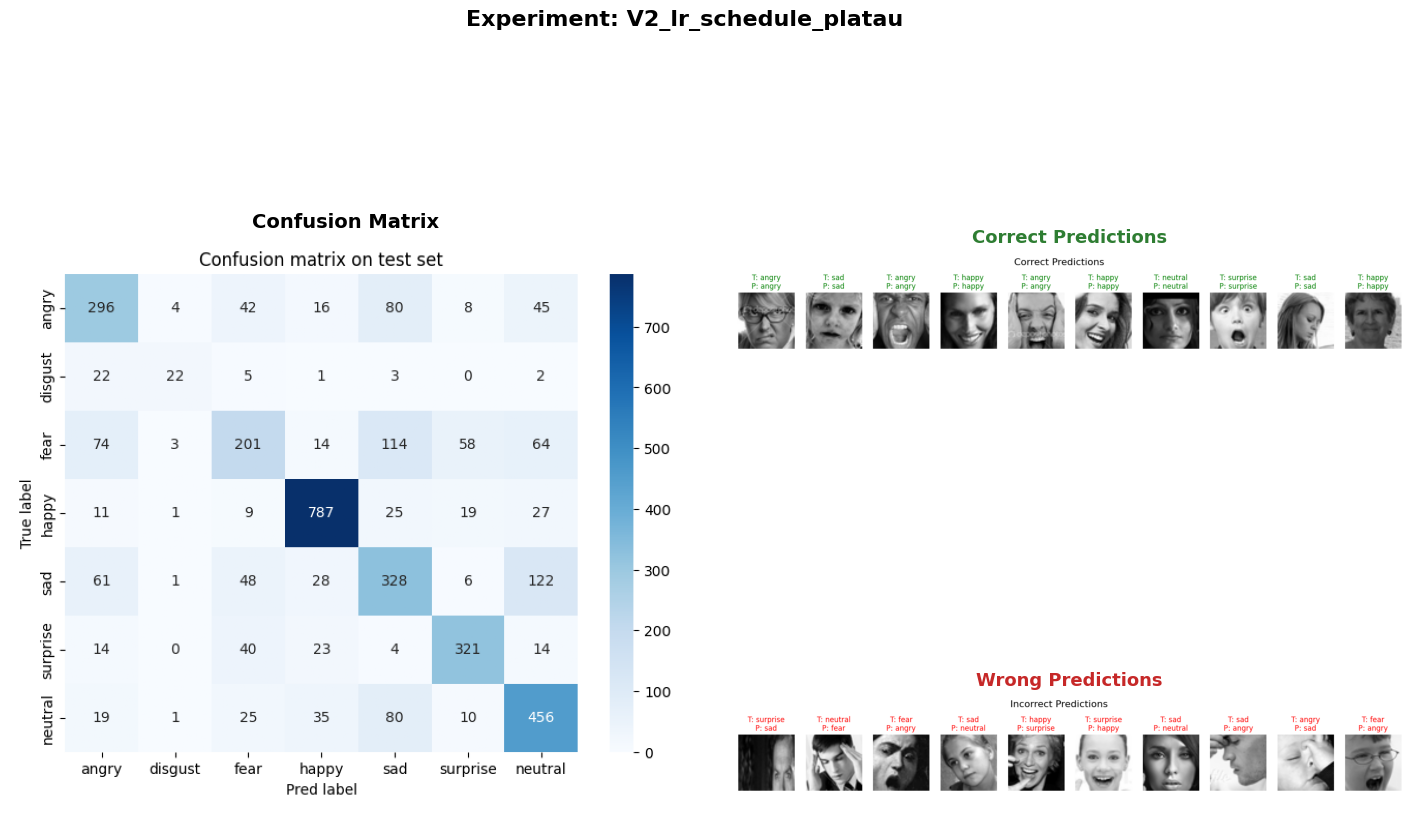

In [5]:
ver_exp_name = "V2_lr_schedule_platau"
path_v2_simplecnn_lrsche_plat = os.path.join(CURRENT_WORKING_DIR, f"outputs/checkpoints/{ver_exp_name}")

plot_cm_preds_image(path_v2_simplecnn_lrsche_plat)

- Nhận xét:

    - **Confusion_matrix**: 
        + Tốt: model dự đoán rất chính xác `happy`, và tốt, giảm dần đối với `neutral` -> `sad | surprise` -> `angry | fear`
        + Tệ: model hầu như không dự đoán `disgust`
    - **Wrong_preds**: 
        + Dự đoán sai hầu hết là không phân biệt được các emotion khá giống nhau, chỉ khác nhau ở một sô chi tiết nhỏ, <br>
        ví dụ: `surprise`-`happy` ở ảnh số 6, Q cũng ko biết sao để phân biệt :)), có thể là lông mày nhíu lên
        + I don't know!

&rarr; Vậy:

- Thống kê xem lớp `disgust` có bị quá ít không?
- Kiến trúc model cần sâu hơn để bắt các chi tiết nhỏ, phân biệt giữa các emotion gần giống nhau!

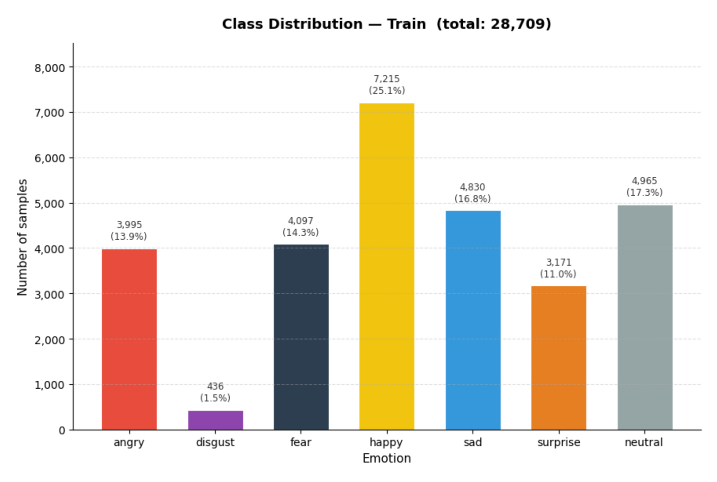

In [ ]:
class_distribution_path = os.path.join(CURRENT_WORKING_DIR, "notebooks/assets/class_distribution.png")

plt.figure(figsize=(9,6))
img = mpimg.imread(class_distribution_path)
img_plot = plt.imshow(img)
plt.axis('off')
plt.show()

&rarr; Ok, dữ liệu bị lệch, phân phối dữ liệu ở train|val|test như nhau,<br>
`disgust` chiếm 1 phần rất nhỏ: **1.5% - 25.5%** so với `happy`

-> Tăng cường dữ liệu -> Cân bằng: dùng **SMOTE**